# **Gestión de Proyectos**

---
---
<!-- Star Wars: Episodio II - El ataque de los clones -->


<!-- script html for image -->
<figure>
<center>

<img src='https://upload.wikimedia.org/wikipedia/commons/2/22/Star_Wars_Episode_VIII_The_Last_Jedi_Word_Logo.svg' width="500" height="300" />

</figure> </center>


Fuente de la imagen: [https://es.wikipedia.org](https://es.wikipedia.org/wiki/Star_Wars:_Episodio_VIII_-_Los_%C3%BAltimos_Jedi)


# **Índice**

---

> [Gestión de Proyectos](#scrollTo=4V0s0pf2KcsE)
<br>
>>
>> [0 - Target ](#scrollTo=zvmH00EJKcsG&line=2&uniqifier=1)
>>
>> [1 - Test de hipótesis](#scrollTo=ZE66e_kjKcsI)
>>
>>> [1.1. Single-Sample, One-Sided Test ](#scrollTo=F3bg6EF-KcsJ&line=1&uniqifier=1)
>>>
>>> [1.2. Pruebas de dos colas](#scrollTo=8hN5gjeFKcsX&line=1&uniqifier=1)
>>
>> [2 - Pruebas de dos muestras](#scrollTo=EBQ0z9I5KcsZ&line=1&uniqifier=1)
>>
>> [3 - Pruebas emparejadas](#scrollTo=ylxu-1jQKcsb&line=1&uniqifier=1)
>>
>> [4 - Referencias](#scrollTo=0MQGbWQSKcsd&line=1&uniqifier=1)
>>

# 0 - Target

Entender el test de hipotesis p-value

# 1 - Test de Hipótesis

## 1.1. Single-Sample, One-Sided Tests

Imagínate que los estudiantes han terminado su año escolar y se les pide que califiquen su clase de estadística en una escala entre -5 (fatal) y 5 (fantástico). La clase de estadística se imparte en línea a decenas de miles de estudiantes, por lo que para evaluar su éxito, deberemos tomar una muestra aleatoria de 50 calificaciones.

<img src="https://github.com/pifparfait/IL3/blob/main/valorp.png?raw=true" style="max-width:100%;"/>

Ejecuta el siguiente código para extraer 50 muestras.

Min:-5
Max:5
Media:0.84


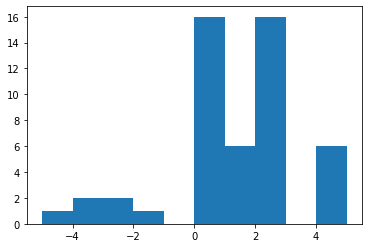

In [ ]:
#importamos las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(123456)
lo = np.random.randint(-5, -1, 6)
mid = np.random.randint(0, 3, 38)
hi = np.random.randint(4, 6, 6)
sample = np.append(lo,np.append(mid, hi))

print("Min:" + str(sample.min()))
print("Max:" + str(sample.max()))
print("Media:" + str(sample.mean()))

plt.hist(sample)
plt.show()

Una pregunta que podríamos hacernos de inmediato es: "¿Cuánto les gusta la clase a los estudiantes"? En este caso, las posibles calificaciones están entre -5 y 5, con una calificación "neutral" de 0. En otras palabras, si nuestra calificación promedio es superior a cero, los estudiantes tienden a disfrutar del curso.

En nuestro caso, podemos decir que a la gente le gustó la clase en estos datos ya que la puntuación media está por encima de 0. Visto estos datos, uno podría concluir que la calificación media es positiva.

Sin embargo, hay un punto importante a tener en cuenta: esto es solo una muestra, y hacer una declaración sobre una única muestra es arriesgado para generalizar. Lo que queremos saber es si dicha muestra es representativa para la populación. Notar esto será nuestro pan de cada día en la vida real cuando a la hora de analizar datos. Dificílmente tendremos acceso a la totalidad de ellos.

Entonces, ¿cómo uno puede probar su creencia de que la **muestra** y su resultado reflejan el hecho de que el curso tiende a obtener buenas evaluaciones y que, la media de su **población** es positiva?  ***De forma general, ¿cómo podemos asegurarnos que esta muesta es representativa?***

**Empezamos definiendo dos hipótesis**:

* La hipótesis *nula* (**H <sub> 0 </sub>**) es cuando la media de la población para todas las calificaciones es *no* y mayor que 0. El hecho de que nuestra media muestral es mayor que esto se debe al azar en nuestra selección de muestras.

* La hipótesis *alternativa* (**H <sub> 1 </sub>**) significa que la media de la población es en realidad mayor que 0, y el hecho de que la media de nuestra muestra sea mayor que esto significa que nuestra muestra detectó correctamente esta tendencia.

Estas hipótesis pueden ser escritas como expresiones mutuamente excluyentes de esta forma:

\begin{equation}H_{0}: \mu \le 0 \\ H_{1}: \mu > 0 \end{equation}

\\

Entonces, ¿cómo probamos estas hipótesis? Debido a que son mutuamente excluyentes, si podemos demostrar que la hipótesis nula probablemente no sea cierta, entonces podemos rechazarlo y concluir que a la gente realmente le gusta nuestro curso en línea. ¿Pero cómo se puede hacer?

Si la hipótesis *nula* es cierta, la distribución de muestreo para calificaciones con un tamaño de muestra de $50$ será una distribución normal con una media de 0. 

<br>

$\bbox{Ejemplo.}$ 

Ejecuta el siguiente código para visualizar esto, con la media de 0 mostrada en amarillo (Linea discontinua).

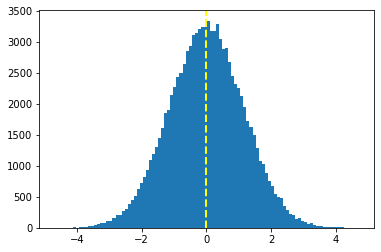

In [ ]:
#El código solo genera una distribución normal con una media de 0 y una desviación estándar 
#que hace que se aproxime a una distribución de muestreo de 50 medias aleatorias entre -5 y 5.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

pop = np.random.normal(0, 1.15, 100000)
plt.hist(pop, bins=100)
plt.axvline(pop.mean(), color='yellow', linestyle='dashed', linewidth=2)
plt.show()

Esta gráfica ilustra todos los resultados de *muestra* que se podría obtener si la hipótesis nula fuera cierta (es decir, la media de la población de calificación es en realidad 0). Ten en cuenta que si la hipótesis nula es cierta, todavía es *posible* obtener una muestra con una media que va desde un poco más de -5 a un poco menos de 5. La pregunta es ¿cómo de tan *probable* es obtener una muestra con una media tan alta para la muestra de las 50 calificaciones bajo la hipótesis nula? Y ¿cómo de tan improbable *tendría* que ser para que concluyamos que el valor nulo es, de hecho, una explicación deficiente para nuestros datos?

Para ello, **mediremos la distancia desde la media en desviaciones estándar**, por lo que, necesitaremos averiguar cuántas desviaciones estándar por encima de la media poblacional hipotetizada nula de 0 es nuestra media muestral, y medir el área bajo la curva de distribución desde este punto en adelante. Esto nos dará la probabilidad de observar una media que es *al menos* tan alta como la media de nuestra muestra. Llamaremos al número de desviaciones estándar por encima de la media donde se encuentra nuestra media muestral *estadístico de prueba* (o a veces simplemente *estadístico t*), y llamaremos *valor p*, en inglés *p-value*, al área bajo la curva desde este punto (que representa la probabilidad de observar un muestra significa este alto o mayor).

Entonces,  **el *valor p* nos dice qué tan probable es la media de nuestra muestra cuando la hipótesis nula es verdadera,** pero necesitamos establecer un umbral por debajo del cual consideramos que esto es demasiado improbable para ser explicado solo por el azar. Llamaremos a este umbral nuestro **valor crítico**, y generalmente lo indicaremos usando la letra griega alfa (**$\alpha$**). Puedes utilizar cualquier valor que consideres apropiado para **$\alpha$**; normalmente se utiliza un valor de 0,05 (5%), pero este valor no tiene nada de especial.

<br>
<p> <mark>IMPORTANTE</mark> </p>
<hr>

* Calcularemos el **estadístico $t$** mediante la realización de una prueba estadística. Técnicamente, cuando se conoce la desviación estándar de la población, la llamamos **prueba $z$** (porque una distribución *normal*, a menudo se denomina distribución *$z$* y se mide la varianza de la media en múltiplos de la desviación estándar conocida como *puntuaciones $z$*).

* Cuando no se conoce la desviación estándar de la población, la prueba se denomina **prueba t** y se basa en una versión ajustada de una distribución normal llamada *distribución $t$ de Student*, en la que la distribución se "aplana" y permite una mayor variación de la muestra dependiendo de su tamaño. Generalmente, con un tamaño de muestra de 30 o más, una prueba $t$ es aproximadamente equivalente a una prueba $z$.

\\

Específicamente, en este caso realizaremos una prueba de *muestra única* (comparación la media de una muestra única de calificaciones con la media de la población hipotetizada), y es una prueba de *una cola* (verificación para ver si la media de la muestra es *mayor que* la media de la población hipotética nula, en otras palabras, en la cola *derecha* de la distribución).

La fórmula general para la **prueba $t$** de una sola cola y una única muestra es:

\begin{equation}t = \frac{\bar{x} - \mu}{s \div \sqrt{n}} \end{equation}

\\

En esta fórmula, tenemos:

* $\bar{x}$ es la media de la muestra

* **&mu;** es la media de la población

* **s** es la desviación estándar y

* **n** es el tamaño de la muestra. 

\\

Se puede pensar en el numerador de esta ecuación (la expresión en la parte superior de la fracción) como una **señal** (información), y el denominador (la expresión en la parte inferior de la fracción) como **ruido**. La señal mide la diferencia entre la estadística y el valor hipotético nulo, y el ruido representa la varianza aleatoria en los datos en forma de desviación estándar (o error estándar). El estadístico $t$ es la relación entre la señal y el ruido y, mide el número de errores estándar entre el valor de hipótesis nula y la media de la muestra observada. Un valor grande indica que el "resultado" o "señal" es mucho mayor de lo que normalmente se esperaría por casualidad.

La mayoría de los lenguajes de programación utilizados para el análisis estadístico incluyen funciones para realizar una *prueba $t$*, por lo que rara vez es necesario calcular manualmente los resultados mediante la fórmula.

Ejecuta el siguiente código para llevar a cabo una *prueba $t$* de muestra única que compare la media de nuestra muestra para las calificaciones con una media de población hipotética de 0, y visualiza el estadístico $t$ resultante en la distribución normal para la hipótesis nula.



t-statistic:2.811370475454282
p-value:0.003537


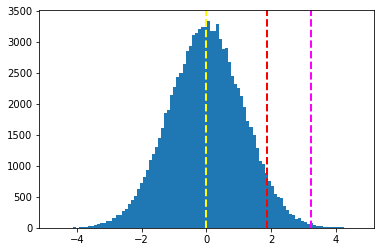

In [ ]:
#importamos las librerias necesarias
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# T-Test
t,p = stats.ttest_1samp(sample, 0)
# ttest_1samp es de 2 colas, por lo que la mitad del valor p resultante para obtener un valor p de 1 cola
p1 = '%f' % (p/2)
print ("t-statistic:" + str(t))
print("p-value:" + str(p1))

# Cálculo de un intervalo de confianza del 90%. El 10% de la probabilidad está fuera de esto, el 5% en cada cola.
ci = stats.norm.interval(0.90, 0, 1.15)
plt.hist(pop, bins=100)

#mostrar la media poblacional hipotética
plt.axvline(pop.mean(), color='yellow', linestyle='dashed', linewidth=2)

# muestre el umbral del intervalo de confianza de la cola derecha: el 5% 
#de probabilidad está debajo de la curva a la derecha de este.
plt.axvline(ci[1], color='red', linestyle='dashed', linewidth=2)

# muestre el estadístico t - el valor p es el área bajo la curva a la derecha de este
plt.axvline(pop.mean() + t*pop.std(), color='magenta', linestyle='dashed', linewidth=2)
plt.show()

En la gráfica del la celda anterior, la línea amarilla muestra la media de la población para la hipótesis nula. El área debajo de la curva a la derecha de la línea roja representa el valor crítico de 0.05 (o 5%). La línea magenta indica cuán mayor es la media de la muestra en comparación con la media de la población hipotetizada. Esto se calcula como el *estadístico $t$* multiplicado por la desviación estándar. El área debajo de la curva a la derecha encapsula el **valor $p$** calculado en este caso.

Entonces, **¿qué deberíamos concluir con estos resultados?**

Bueno, si el *valor p* es menor que nuestro valor crítico de 0.05, significa que bajo la hipótesis nula, la probabilidad de observar una media muestral tan alta como lo hicimos por azar es baja. Esa es una buena señal para nosotros, porque significa que nuestra muestra es poco probable bajo el valor nulo y, por lo tanto, el valor nulo es una mala explicación para los datos. Podemos *rechazar* con seguridad la hipótesis nula a favor de la hipótesis alternativa; hay suficientes evidencias para sugerir que la media de la población para nuestras calificaciones de clase es mayor que 0.

Por el contrario, si el *valor $p$* es mayor que el valor crítico, *no rechazaremos la hipótesis nula* y conclureimos que la calificación media no es mayor que 0. 

<br>
<p> <mark>IMPORTANTE</mark> </p>
<hr>

Ten en cuenta que, **en realidad nunca *aceptamos* la hipótesis nula,** simplemente concluimos **¡que no hay pruebas suficientes para rechazarlo!**

## 1.2. - Pruebas de dos colas
La prueba anterior fue un ejemplo de una prueba de una cola en la que el *valor $p$* representa el área debajo de una cola de la curva de distribución. En este caso, el área en cuestión está debajo de la cola derecha porque la hipótesis alternativa que estábamos tratando de mostrar era que la media de la población real es *mayor que* la media del escenario de la hipótesis nula.

Supongamos que replanteamos nuestras hipótesis de esta manera:

* La hipótesis *nula* (**H<sub> 0 </sub>**) es que la media de la población para todas las calificaciones es 0, y el hecho de que la media de nuestra muestra sea mayor o menor que esto puede explicarse por el azar en nuestra selección de muestras.

* La hipótesis *alternativa* (**H <sub> 1 </sub>**) es que la media de la población no es igual a 0.

Podemos escribir esto como expresiones mutuamente excluyentes como:

\begin{equation}H_{0}: \mu = 0 \\ H_{1}: \mu \neq 0 \end{equation}

\\

**¿Por qué haríamos esto?** Porque en la prueba que realizamos anteriormente, solo podríamos rechazar la hipótesis nula si tuviéramos calificaciones realmente *positivas*, pero **¿y si nuestros datos de muestra parecieran realmente *negativos*?** Sería un error dar la vuelta y ejecutar una prueba de una cola al revés, para calificaciones negativas. En cambio, realizamos una prueba diseñada para tal pregunta: **una prueba de dos colas.**

<br>
<p> <mark>OBSERVACIONES</mark> </p>
<hr>

**En una prueba de dos colas, estamos dispuestos a rechazar la hipótesis nula si el resultado es significativamente *mayor* o *menor* que la hipótesis nula.** Por tanto, nuestro valor crítico (5%) se divide en dos: el 2.5% superior de la curva y el 2.5% inferior de la curva. Mientras nuestro estadístico de prueba esté en esa región, estamos en el extremo 5% de los valores (p <.05) y rechazamos la hipótesis nula. En otras palabras, nuestro *valor $p$* ahora debe estar por debajo de .025, pero puede estar en cualquier cola de la distribución. Por conveniencia, usualmente "duplicamos" el *valor $p$* en una prueba de dos colas para no tener que recordar esta regla y aún comparar con .05 (esto se conoce como un "*valor $p$ de dos colas*") . De hecho, se asume que esto se ha hecho en todos los análisis estadísticos a menos que se indique lo contrario.

<br>

$\bbox{Ejemplo.}$ 

El siguiente código muestra los resultados de una prueba de muestra única de dos colas de nuestras calificaciones de clase. Ten en cuenta que la función ***ttest_1samp*** en la biblioteca ***stats*** devuelve un *valor $p$* de 2 colas por defecto (por eso lo dividimos a la mitad en el ejemplo anterior).


t-statistic:2.811370475454282
p-value:0.007074


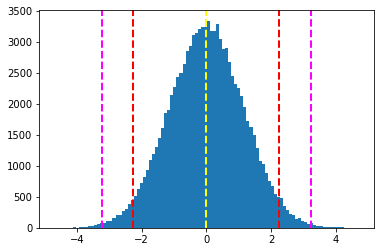

In [ ]:
#importamos las librerias necesarias
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# T-Test - Es la prueba T-Test
t,p = stats.ttest_1samp(sample, 0)
print ("t-statistic:" + str(t))

# ttest_1samp es de 2 colas
print("p-value:" + '%f' % p)

# Calcule un intervalo de confianza del 95%. 50% de la probabilidad está fuera de esto, 2.5% en cada cola
ci = stats.norm.interval(0.95, 0, 1.15)
plt.hist(pop, bins=100)

# Visualizacion de la media poblacional hipotética
plt.axvline(pop.mean(), color='yellow', linestyle='dashed', linewidth=2)

# Visualizacion de los umbrales del intervalo de confianza: el 5% de la probabilidad 
#está por debajo de la curva fuera de estos.
plt.axvline(ci[0], color='red', linestyle='dashed', linewidth=2)
plt.axvline(ci[1], color='red', linestyle='dashed', linewidth=2)

# Visualizacion de los umbrales de la estadística t - el valor p es el área bajo la curva fuera de estos
plt.axvline(pop.mean() - t*pop.std(), color='magenta', linestyle='dashed', linewidth=2)
plt.axvline(pop.mean() + t*pop.std(), color='magenta', linestyle='dashed', linewidth=2)
plt.show()

Aquí vemos que nuestro valor $p$ de 2 colas fue claramente menor que 0.05; por lo que rechazamos la hipótesis nula.

Puedes notar que al duplicar el valor $p$ en una prueba de dos colas hace que sea más difícil rechazar el valor nulo. Esto es verdad; se requiere más evidencia porque estamos haciendo una pregunta más complicada. 

# 2 - Pruebas de dos muestras
En los dos ejemplos anteriores, comparamos una estadística de una sola muestra de datos con un parámetro de población con hipótesis nula. A veces, es posible que desees comparar dos muestras entre sí.

Por ejemplo, supongamos que algunos de los estudiantes que tomaron el curso de estadística habían estudiado matemáticas anteriormente, mientras que otros estudiantes no tenían experiencia previa en matemáticas. Podrías plantear la hipótesis de que las calificaciones de los estudiantes que habían estudiado matemáticas anteriormente son significativamente más altas que las calificaciones de los estudiantes que no lo hicieron.

* La hipótesis *nula* (**H <sub> 0 </sub>**) es que la calificación promedio de la población para los estudiantes con estudios de matemáticas previos no es mayor que la calificación promedio de la población para los estudiantes sin ninguna experiencia en matemáticas, y el hecho de que nuestra media muestral para estudiantes de matemáticas sea mayor que nuestra media muestral para estudiantes que no son matemáticos puede explicarse por el azar en nuestra selección de muestra.

* La hipótesis *alternativa* (**H <sub> 1 </sub>**) es que la calificación promedio de la población para los estudiantes con estudios de matemáticas previos es mayor que la calificación promedio de la población para los estudiantes sin ninguna experiencia en matemáticas.

Se llega a:

\begin{equation}H_{0}: \mu_{1} \le \mu_{2} \\ H_{1}: \mu_{1} > \mu_{2} \end{equation}

\\

<br>

$\bbox{Ejemplo.}$ 

Veamos en detalle la siguiente situación: Esta es una prueba unilateral que compara dos muestras. 

Para realizar esta prueba, tomaremos dos muestras. Una muestra contiene 100 calificaciones para estudiantes que han estudiado matemáticas anteriormente y, la otra muestra, contiene 100 calificaciones para estudiantes sin experiencia en matemáticas.

No entraremos aquí en la fórmula de *prueba-estadística*, pero es esencialmente la misma que la anterior, adaptada para incluir información de ambas muestras. Podemos probar esto fácilmente en la mayoría de los paquetes de software usando el comando para una prueba $t$ de "muestras independientes".


media muestral no matemática:66.04066361023553
media de la muestra de matemáticas:66.52069665713476
t-statistic:2.140008413392296
p-value:0.016789


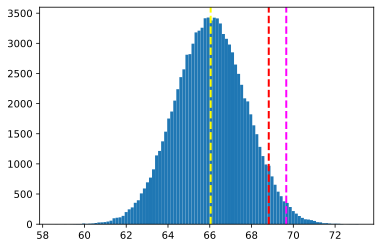

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # Para pintar las graficas en muy buena resolución

np.random.seed(123)
nonMath = np.random.normal(66.0, 1.5, 100)
math = np.random.normal(66.55, 1.5, 100)
print("media muestral no matemática:" + str(nonMath.mean()))
print("media de la muestra de matemáticas:" + str(math.mean()))

# Prueba T independiente
t,p = stats.ttest_ind(math, nonMath)

# ttest_ind es de 2 colas, por lo que la mitad del valor p resultante para obtener un valor p de 1 cola
p1 = '%f' % (p/2)
print("t-statistic:" + str(t))
print("p-value:" + str(p1))

pop = np.random.normal(nonMath.mean(), nonMath.std(), 100000)
# Calcule un intervalo de confianza del 90%. El 10% de la probabilidad está fuera de esto, el 5% en cada cola.

ci = stats.norm.interval(0.90, nonMath.mean(), nonMath.std())
plt.hist(pop, bins=100)
# Visualizacion de la media poblacional hipotética
plt.axvline(pop.mean(), color='yellow', linestyle='dashed', linewidth=2)

#Visualizacion del umbral del intervalo de confianza de la cola derecha: el 5% de probabilidad 
#está debajo de la curva a la derecha de este.
plt.axvline(ci[1], color='red', linestyle='dashed', linewidth=2)

# Visualizacion del estadístico t - el valor p es el área bajo la curva a la derecha de este
plt.axvline(pop.mean() + t*pop.std(), color='magenta', linestyle='dashed', linewidth=2)
plt.show()

Puedes interpretar los resultados de esta prueba de la misma manera que para la prueba anterior de una sola muestra y una cola. Si el *valor $p$* (el área debajo de la curva a la derecha de la línea magenta) es menor que nuestro valor crítico (**&alpha;**) de 0.05 (el área debajo de la curva a la derecha de la línea roja), entonces la diferencia no puede explicarse únicamente por casualidad. Por lo que podemos rechazar la hipótesis nula y concluir que los estudiantes con experiencia previa en matemáticas se desempeñan mejor en promedio que los estudiantes sin ella.

Alternativamente, uno siempre puede comparar dos grupos y *no* especificar una dirección (es decir, de dos colas). Si se hiciera esto, como se indicó anteriormente, simplemente podría duplicar el *valor p* (ahora .001), y verá que aún puede rechazar la hipótesis nula.

# 3 - Pruebas emparejadas
En la prueba de dos muestras que realizamos anteriormente, las muestras fueron independientes; en otras palabras, no hubo relación entre las observaciones de la primera muestra y las observaciones de la segunda muestra. A veces, es posible que desees comparar las diferencias estadísticas entre las observaciones relacionadas antes y después de algún cambio que creas que podría influir en los datos.

Por ejemplo, supongamos que nuestros estudiantes hicieron un examen a mitad de curso y luego otro examen de fin de curso. Uno puede plantear la hipótesis de que los estudiantes mejorarán sus calificaciones en el examen de fin de trimestre, después de haber realizado estudios adicionales. Podríamos evaluar una mejora general en promedio en todos los estudiantes con una prueba independiente de dos muestras, pero una prueba más apropiada sería comparar las dos puntuaciones de las pruebas para cada estudiante individual.

Para lograr esto, necesitaremos crear dos muestras; uno para puntuar las notas en el examen de mitad de curso, y otra para las notas del examen de fin de curso. Luego, necesitaremos comparar las muestras de tal manera que podamos cotejar entre si cada par de observaciones del mismo estudiante.

<br>
<p> <mark>IMPORTANTE</mark> </p>
<hr>

Lo enunciado se conoce como *prueba $t$* de muestras pareadas o *prueba $t$ de muestras dependientes*. **Técnicamente, prueba si los *cambios* tienden a ser positivos o negativos.**

<br>

$\bbox{Ejemplo.}$ 

Si continuamos con el ejemplo:

t-statistic:2.3406857739212583
p-value:0.010627


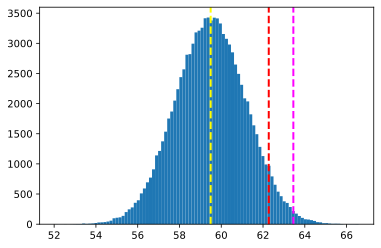

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

np.random.seed(123)
midTerm = np.random.normal(59.45, 1.5, 100)
endTerm = np.random.normal(60.05, 1.5, 100)

# Prueba emparejada (relacionada)
t,p = stats.ttest_rel(endTerm, midTerm)

# ttest_rel es de 2 colas, por lo que la mitad del valor p resultante para obtener un valor p de 1 cola
p1 = '%f' % (p/2)
print("t-statistic:" + str(t))
print("p-value:" + str(p1))

pop = np.random.normal(midTerm.mean(), midTerm.std(), 100000)

# Cálculo de un intervalo de confianza del 90%. El 10% de la probabilidad está fuera de esto, el 5% en cada cola.
ci = stats.norm.interval(0.90, midTerm.mean(), midTerm.std())
plt.hist(pop, bins=100)

# Visualización de la media poblacional hipotética
plt.axvline(pop.mean(), color='yellow', linestyle='dashed', linewidth=2)

# Visualización del umbral del intervalo de confianza de la cola derecha: el 5% 
#de probabilidad está debajo de la curva a la derecha de este.
plt.axvline(ci[1], color='red', linestyle='dashed', linewidth=2)

# Visualizacion del estadístico t - el valor p es el área bajo la curva a la derecha de este
plt.axvline(pop.mean() + t*pop.std(), color='magenta', linestyle='dashed', linewidth=2)
plt.show()

De hecho, podemos darnos cuenta que las puntuaciones mejoraron, por lo que podemos rechazar la hipótesis nula.

# 4 - Referencias

Se recomienda leer las siguientes referencias:

1.  https://machinelearningmastery.com/

2.  https://jdvelasq.github.io/courses/index.html